# RiskLens — Risk Analysis Walkthrough

A short tour of what RiskLens does, using **BTC-USD** as the example asset. The goal here is to give you the full story in under 10 minutes — what data goes in, what models come out, and how to read the headline result.

This notebook does **not** dive into methodology. For that, follow the pointers at the end to the three deep-dive notebooks.

**The one thing to take away:** the risk number you report depends on **which model** you use **and over what horizon**. One number in isolation is not useful — a *range* across models and horizons is.


## 1. Data

Daily OHLCV from Yahoo Finance, cleaned, with log-returns computed.


In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.fetch import fetch_asset_data
from src.data.process import clean_market_data, add_returns
from src.analytics.risk_metrics import (
    annualized_volatility, max_drawdown, drawdown_series,
    rolling_volatility, sharpe_ratio,
)
from src.analytics.monte_carlo import simulate_paths, simulation_summary, fit_garch
from src.analytics.ms_garch import fit_ms_garch
from src.analytics.evt import evt_summary
from src.analytics.xgb_var import fit_quantile_model

sns.set_theme(style="whitegrid")
%matplotlib inline

TICKER = "BTC-USD"
SEED = 42
N_SIMS = 10_000

df = add_returns(clean_market_data(fetch_asset_data(TICKER)))
close, returns = df["close"], df["returns"]
initial_price = close.iloc[-1]

print(f"{TICKER}: {len(df)} trading days, initial price ${initial_price:,.0f}")


BTC-USD: 1824 trading days, initial price $74,905


## 2. Historical Snapshot

What does BTC's own history say about its risk? These are *backward-looking* numbers — they describe what already happened, not what will happen next.


In [9]:
print(f"Annualized volatility : {annualized_volatility(returns):.2%}")
print(f"Max drawdown          : {max_drawdown(close):.2%}")
print(f"Sharpe ratio          : {sharpe_ratio(returns):.2f}")
print(f"Worst single day      : {returns.min():.2%}")
print(f"Best single day       : {returns.max():.2%}")


Annualized volatility : 46.60%
Max drawdown          : -76.63%
Sharpe ratio          : 0.32
Worst single day      : -15.97%
Best single day       : 14.54%


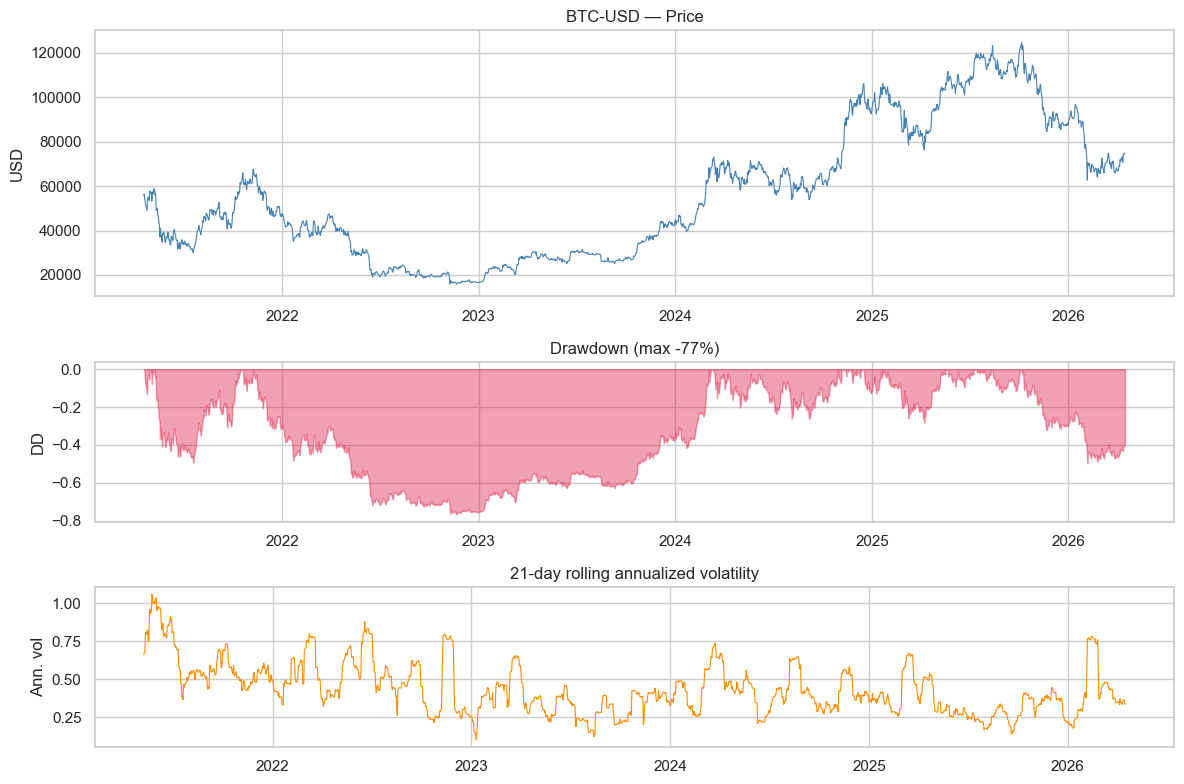

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1.2, 1.2]})

axes[0].plot(close.index, close.values, color="steelblue", linewidth=0.8)
axes[0].set_title(f"{TICKER} — Price"); axes[0].set_ylabel("USD")

dd = drawdown_series(close)
axes[1].fill_between(dd.index, dd.values, 0, color="crimson", alpha=0.4)
axes[1].set_title(f"Drawdown (max {max_drawdown(close):.0%})"); axes[1].set_ylabel("DD")

rv = rolling_volatility(returns, window=21)
axes[2].plot(rv.index, rv.values, color="darkorange", linewidth=0.8)
axes[2].set_title("21-day rolling annualized volatility"); axes[2].set_ylabel("Ann. vol")

plt.tight_layout(); plt.show()


> **Takeaway.** BTC is a high-volatility asset (~45% annualized) with a history of severe drawdowns. Volatility itself is time-varying — the rolling-vol panel shows long calm stretches punctuated by sharp spikes. Any sensible forward-looking risk model needs to respect both the fat tails *and* the clustering of volatility.


## 3. The Three Tiers

RiskLens runs forward-looking Monte Carlo simulations under three progressively richer models. Each tier adds one layer the previous one misses.

| Tier | Volatility | Shocks | What it captures |
|------|-----------|--------|------------------|
| **Baseline** | Constant σ | Normal | Textbook GBM — symmetric risk, no clustering |
| **GARCH + t** | Time-varying GARCH(1,1) | Student-t | Vol clustering + fat tails |
| **MS-GARCH + EVT** | Regime-switching GARCH | GPD tails per regime | Regime shifts + extreme-value tail modeling |

Each tier's output is a distribution of possible final prices. From that distribution we read **VaR** (the loss threshold crossed with 5% or 1% probability) and **CVaR** (the average loss in those worst cases).


## 4. Results — 21 Days vs 252 Days

The single most important insight in this project: **the ranking of the tiers depends on the horizon**.

- At **short horizons** (e.g. 21 days ≈ one trading month), GARCH has not yet mean-reverted and MS-GARCH's regime signal is still fresh — both produce visibly different tails from Baseline.
- At **long horizons** (252 days ≈ one year), GARCH mean-reverts to its long-run σ and the Central Limit Theorem smooths out shock-distribution differences. The tiers converge.

We run all three tiers at both horizons and compare.


In [11]:
garch_params = fit_garch(returns)
ms_params = fit_ms_garch(returns, n_regimes=2, seed=SEED)

tier_configs = {
    "Baseline":       {"volatility_model": "constant"},
    "GARCH+t":        {"volatility_model": "garch", "garch_params": garch_params},
    "MS-GARCH+EVT":   {"volatility_model": "ms_garch", "ms_garch_params": ms_params},
}

results = {}  # results[horizon][tier] = final_prices
for horizon in [21, 252]:
    results[horizon] = {}
    for name, cfg in tier_configs.items():
        paths = simulate_paths(close, returns, n_days=horizon, n_simulations=N_SIMS, seed=SEED, **cfg)
        results[horizon][name] = paths.iloc[-1]

print("Done — 3 tiers x 2 horizons simulated.")


Done — 3 tiers x 2 horizons simulated.


In [12]:
# Comparison table
rows = []
for horizon, tiers in results.items():
    for name, fp in tiers.items():
        s95 = simulation_summary(fp, initial_price, 0.95)
        s99 = simulation_summary(fp, initial_price, 0.99)
        rows.append({
            "Horizon": f"{horizon}d", "Tier": name,
            "VaR 95%": f"{s95['var']:.1%}", "CVaR 95%": f"{s95['cvar']:.1%}",
            "VaR 99%": f"{s99['var']:.1%}", "CVaR 99%": f"{s99['cvar']:.1%}",
        })
pd.DataFrame(rows)


,Horizon,Tier,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
0,21d,Baseline,-19.9%,-24.1%,-27.2%,-29.9%
1,21d,GARCH+t,-14.6%,-22.6%,-27.3%,-38.5%
2,21d,MS-GARCH+EVT,-19.6%,-26.2%,-29.6%,-36.1%
3,252d,Baseline,-51.6%,-59.7%,-65.2%,-69.7%
4,252d,GARCH+t,-45.4%,-59.1%,-67.2%,-79.8%
5,252d,MS-GARCH+EVT,-62.3%,-71.0%,-75.9%,-80.6%


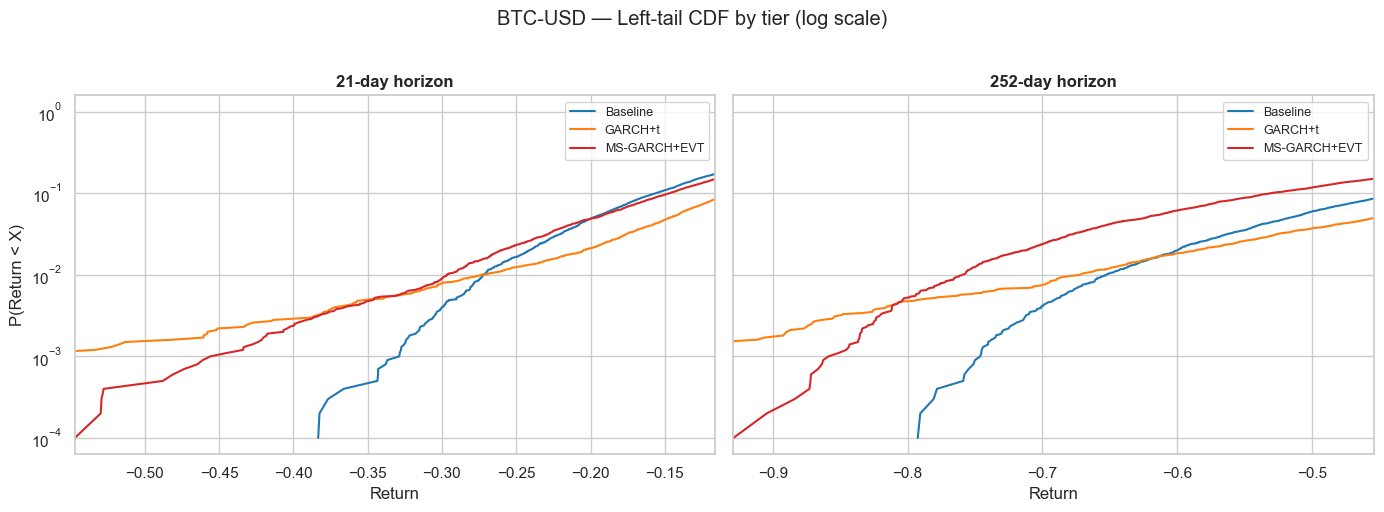

In [13]:
# Side-by-side left-tail CDF (log scale) — where tier differences live
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {"Baseline": "#1f77b4", "GARCH+t": "#ff7f0e", "MS-GARCH+EVT": "#d62728"}

for ax, horizon in zip(axes, [21, 252]):
    for name, fp in results[horizon].items():
        ret = ((fp - initial_price) / initial_price).sort_values()
        cdf = np.arange(1, len(ret) + 1) / len(ret)
        ax.plot(ret.values, cdf, label=name, color=colors[name], linewidth=1.5)
    ax.set_xlim(ret.quantile(0.0), ret.quantile(0.15))
    ax.set_yscale("log")
    ax.set_title(f"{horizon}-day horizon", fontweight="bold")
    ax.set_xlabel("Return"); ax.legend(fontsize=9)

axes[0].set_ylabel("P(Return < X)")
fig.suptitle(f"{TICKER} — Left-tail CDF by tier (log scale)", y=1.02)
plt.tight_layout(); plt.show()


> **Takeaway.** At 21 days, MS-GARCH+EVT sits clearly deeper in the left tail than Baseline — you can see the red curve above the blue one on the left panel. At 252 days the three curves collapse onto each other in the right panel. **Same asset, same data, same confidence level — the "right" risk number depends on the horizon.** This is why the app asks you for a horizon before picking a tier.


## 5. Cross-checks — EVT and XGBoost (1-day VaR)

The Monte Carlo tiers above are *horizon* forecasts — a distribution of prices 21 or 252 days from today. They rest on a handful of modeling assumptions (distribution family, regime count, etc.).

Two non-MC methods estimate **1-day VaR** directly from history, with different assumptions:

- **EVT (GPD fit on the tail)** — parametric only on the tail, not on the full distribution. Threshold-based.
- **XGBoost quantile regression** — nonparametric; learns the 5th / 1st percentile of next-day returns from lagged features.

If these two agree with the MC tiers *rescaled down to 1 day* (roughly `VaR_1d ≈ VaR_H / √H`), the tiers are internally consistent.


In [14]:
# 1-day VaR from three independent sources
evt_95 = evt_summary(returns, confidence=0.95, threshold_quantile=0.95)
evt_99 = evt_summary(returns, confidence=0.99, threshold_quantile=0.95)
xgb_95 = fit_quantile_model(returns, quantile=0.05, seed=SEED, tune=False)
xgb_99 = fit_quantile_model(returns, quantile=0.01, seed=SEED, tune=False)
hist_95 = float(np.quantile(returns.dropna(), 0.05))
hist_99 = float(np.quantile(returns.dropna(), 0.01))

# Rescale MC 252d tier back to 1d via sqrt-time
def mc_1d(fp, conf):
    s = simulation_summary(fp, initial_price, conf)
    return s["var"] / np.sqrt(252)

rows = [
    {"Source": "Historical empirical", "1d VaR 95%": f"{hist_95:.2%}", "1d VaR 99%": f"{hist_99:.2%}"},
    {"Source": "EVT (GPD)",            "1d VaR 95%": f"{evt_95['evt_var']:.2%}", "1d VaR 99%": f"{evt_99['evt_var']:.2%}"},
    {"Source": "XGBoost quantile",     "1d VaR 95%": f"{xgb_95['predicted_var']:.2%}", "1d VaR 99%": f"{xgb_99['predicted_var']:.2%}"},
    {"Source": "MS-GARCH+EVT (MC 252d / √252)",
     "1d VaR 95%": f"{mc_1d(results[252]['MS-GARCH+EVT'], 0.95):.2%}",
     "1d VaR 99%": f"{mc_1d(results[252]['MS-GARCH+EVT'], 0.99):.2%}"},
]
pd.DataFrame(rows).set_index("Source")


,1d VaR 95%,1d VaR 99%
Source,,
Historical empirical,-4.57%,-8.13%
EVT (GPD),-4.59%,-8.16%
XGBoost quantile,-3.06%,-5.63%
MS-GARCH+EVT (MC 252d / √252),-3.93%,-4.78%


> **Takeaway.** Four different methods, broadly the same 1-day VaR ballpark — that's the sanity check. EVT and XGB exist in the project as **validators**, not as rival forecasting tiers. If they disagreed wildly with the MC tier, we would suspect the MC model. For deeper validation (rolling backtest, Kupiec / Christoffersen tests, EVT diagnostics), see `validation_backtesting.ipynb`.


## 6. Which Tier Should I Use?

The horizon-dependent result in §4 produces a practical rule of thumb the app uses:

| If your horizon is... | Use tier | Why |
|----------------------|----------|-----|
| Days to a few weeks | **MS-GARCH+EVT** or **GARCH+t** | Vol clustering + regime state still matter |
| Around a quarter | **GARCH+t** | Vol dynamics partially relevant, regime detection noisier |
| Full year+ | **Baseline** or **GARCH+t** | Differences wash out — extra model complexity buys little |

**Caveat — depth is not calibration.** A tier producing the deepest VaR is not automatically the most accurate one. `validation_backtesting.ipynb` backtests each tier with rolling-window Kupiec / Christoffersen tests and shows which tier is actually well-calibrated at each horizon. `model_diagnosis.ipynb` explains *why* MS-GARCH+EVT can produce very deep VaR and still fail calibration.


## 7. Where to Go Next

This walkthrough is deliberately light. The deep-dive notebooks below each answer one specific methodological question:

1. **[`model_comparison.ipynb`](model_comparison.ipynb)** — controlled studies that isolate the *tail effect* and *vol effect* separately, the 3-tier head-to-head on three assets, seed-robustness across 10 seeds, MS-GARCH internals.
2. **[`horizon_crossover.ipynb`](horizon_crossover.ipynb)** — at exactly which horizon does MS-GARCH+EVT overtake GARCH+t in VaR depth? Maps the crossover per asset and grounds the rule-of-thumb table in §6.
3. **[`validation_backtesting.ipynb`](validation_backtesting.ipynb)** — non-MC cross-checks (EVT diagnostics, XGBoost as a real auditor via SHAP) and rolling-window backtests of each tier with Kupiec and Christoffersen tests.
4. **[`model_diagnosis.ipynb`](model_diagnosis.ipynb)** — why MS-GARCH+EVT fails the backtest despite producing the deepest VaR; failure-mode taxonomy; the project's conclusions.

Supporting docs: [`docs/conclusions.md`](../docs/conclusions.md) for the full prose synthesis, [`docs/assumptions.md`](../docs/assumptions.md) for every modeling choice that affects the numbers above.
